In [3]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import svd
import helpers as stoOpinf

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "text.usetex": False,  
    "mathtext.fontset": "cm",  # to enable Computer Modern / Latin Modern math
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman", "Computer Modern Roman", "DejaVu Serif"],

    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
power_labels = {
    "0p04": list("abcdefghijklmnop"),   # Ca_ac = 0.25 x 10^-3
    "0p07": list("abcdefghijklnop"),    # Ca_ac = 0.66 x 10^-3
    "0p08": list("abcefghijklnop"),     # Ca_ac = 0.67 x 10^-3
    "0p10": list("bcdefhijklmnopq"),    # Ca_ac = 0.83 x 10^-3
    "0p15": list("abcdefghijklmnop"),   # Ca_ac = 1.15 x 10^-3
    "0p18": list("abcdefghijkmnop"),    # Ca_ac = 1.56 x 10^-3
    "0p20": list("abcdefghijklmnop"),   # Ca_ac = 1.76 x 10^-3
    "0p25": list("abcdefghijklmno"),    # Ca_ac = 1.99 x 10^-3
    "0p30": list("abcdefghijklmnop"),   # Ca_ac = 2.84 x 10^-3
    "0p35": list("abcdefhijklmnop"),    # Ca_ac = 3.32 x 10^-3
}

In [6]:
power = "0p10"  

dataset = stoOpinf.QDataset.load(power, power_labels[power]).preprocess()
X, t, x, nx = dataset.Q, dataset.t, dataset.x, dataset.nx
X_split, Xstate_all, X_mean, tt = dataset.Q_split, dataset.Qstate_all, dataset.X_mean, dataset.tt

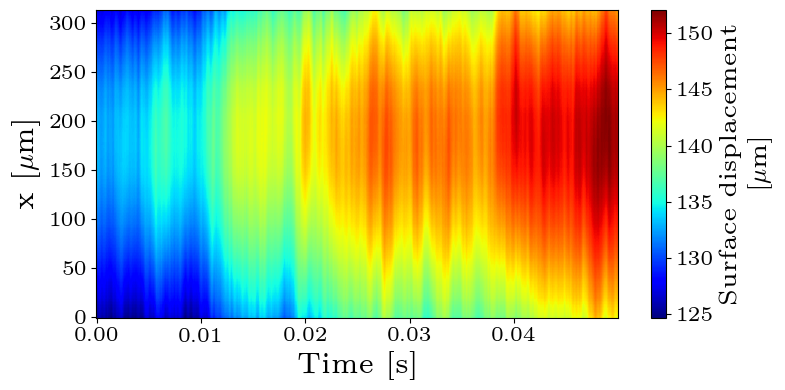

In [13]:
T, X = np.meshgrid(tt, x)
Z = Xstate_all.mean(axis=1)

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)

# 2D colormap
pcm = ax.pcolormesh(
    T, X, Z, shading='auto', cmap='jet'
)
ax.set_xlabel('Time [s]', fontsize=20)
ax.set_ylabel('x [$\\mu$m]', fontsize=20)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('Surface displacement\n[$\\mu$m]', fontsize=18)

plt.tight_layout()
plt.show()

In [14]:
V, S, _ = svd(Xstate_all.reshape(nx, -1), full_matrices=False)
print("Basis computed.")

Basis computed.


In [15]:
# data parameters
_, L, s = Xstate_all.shape      # L: sample size, s: # of time steps
h_test = t[1] - t[0]            # time step

Edata = np.mean(Xstate_all, 1)   # mean of the data

tt_test = tt

# Input signal
f0 = 7
f_input = f0 * 1e6
u_amp = 1
u_input = u_amp * np.cos(2 * np.pi * f_input * tt_test)

In [ ]:
# Hyperparameters
A_reg      = np.logspace(-1, 5, 10)
A_reg_test = 0
B_reg      = 0
N_reg      = np.logspace(0, 10, 10)
H_reg      = 1e6

sigma      = 1

isbilinear = True
isBu       = True
seed_test  = 42

ROM_form = 'A' + ('B' if isBu else '') + ('N' if isbilinear else '')

# Loop ranges
if isBu:
    B_loop = np.arange(1)
    B_reg = np.array([B_reg])
else:
    B_loop = np.array([0])
    B_reg  = np.array([0.0])

# Lambda factory
def get_lambda(ii, jj):
    if isbilinear and isBu:
        return np.array([A_reg_test, B_reg[jj], N_reg[ii]])
    elif isbilinear and not isBu:
        return np.array([A_reg_test, N_reg[ii]])
    elif not isbilinear and isBu:
        return np.array([A_reg[ii], B_reg[jj], 0.0])
    else:
        return np.array([A_reg[ii]])

In [19]:
#### r sweep ####
r_candidates = np.arange(5, 31)
r_results    = {}                    

for r in r_candidates:
    Vr_temp      = V[:, :r]
    
    # Projection of all data onto the reduced basis
    Xr_temp = Vr_temp.T @ Xstate_all.reshape(Vr_temp.shape[0], L * s)    
    Xr_temp = Xr_temp.reshape(r, L, s)

    Er = Xr_temp.mean(axis=1)
    Cr = np.stack([np.cov(Xr_temp[:, :, k])
                        for k in range(s)], axis=2)

    data = stoOpinf.StochasticOpInfTrainingData(Er, Cr, Xr_temp, u_input, Vr_temp, h_test)
    grid = stoOpinf.RegularizationGrid(N_reg, H_reg, B_loop, get_lambda, seed_test)
    results = stoOpinf.run_grid_search(data, grid, isbilinear, isBu, sigma)

    E_error = results['E_error']   # shape (n_outer, n_inner)
    C_error = results['C_error']
    
    best_indices       = np.nanargmin(E_error)
    best_ii, best_jj   = np.unravel_index(best_indices, E_error.shape)

    r_results[r] = {
        'E_error'  : E_error[best_ii, best_jj],
        'C_error'  : C_error[best_ii, best_jj],
        'best_ii'  : best_ii, 'best_jj'  : best_jj,
        'results'  : results,
    }
    print(f"r={r:2d} | mean error={E_error[best_ii, best_jj]:.4e}  "
            f"cov error={C_error[best_ii, best_jj]:.4e}")

r= 5 | mean error=2.5281e-02  cov error=3.2403e-01
r= 6 | mean error=1.2005e-02  cov error=8.3150e-02
r= 7 | mean error=2.3557e-02  cov error=2.6466e-01
r= 8 | mean error=1.1002e-02  cov error=1.2332e-01
r= 9 | mean error=1.3653e-02  cov error=2.3697e-01
r=10 | mean error=1.1985e-02  cov error=1.5028e-01
r=11 | mean error=1.0036e-02  cov error=2.9038e-01
r=12 | mean error=1.1177e-02  cov error=1.2941e-01
r=13 | mean error=1.5316e-02  cov error=2.0336e-01
r=14 | mean error=1.9024e-02  cov error=2.1623e-01
r=15 | mean error=1.4914e-02  cov error=2.8412e-01
r=16 | mean error=1.1426e-02  cov error=1.3108e-01
r=17 | mean error=1.0381e-02  cov error=1.2208e-01
r=18 | mean error=1.1507e-02  cov error=1.1843e-01
r=19 | mean error=1.1545e-02  cov error=1.0525e-01
r=20 | mean error=1.1617e-02  cov error=1.4701e-01
r=21 | mean error=1.4293e-02  cov error=1.1303e+00
r=22 | mean error=1.2320e-02  cov error=6.4822e-02
r=23 | mean error=1.0891e-02  cov error=5.7532e-02
r=24 | mean error=1.3051e-02  c

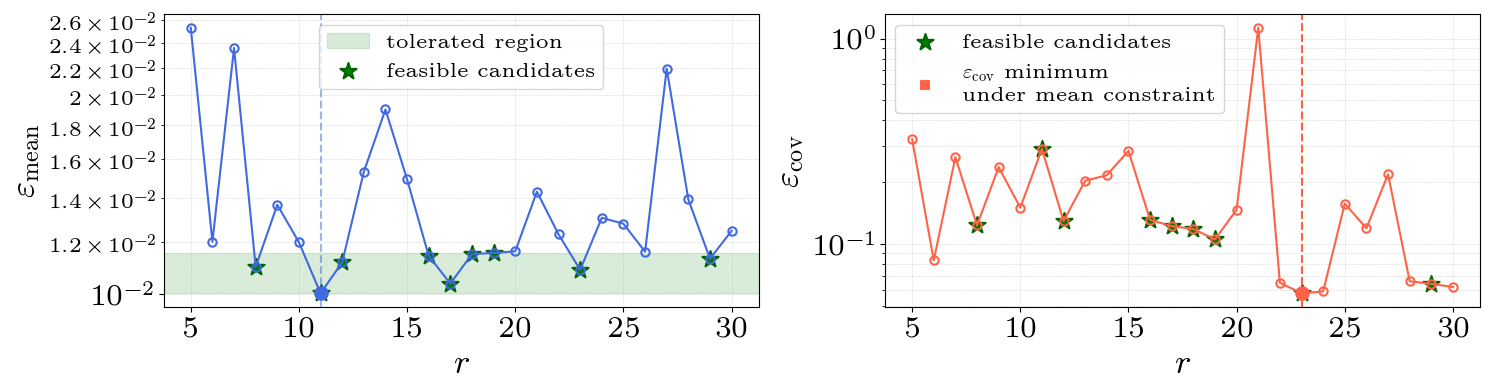

In [21]:
r_candidates = np.array(sorted(r_results.keys()))

E_errs = np.array([r_results[r]['E_error'] for r in r_candidates])
C_errs = np.array([r_results[r]['C_error'] for r in r_candidates])

E_min = np.min(E_errs)
E_max = np.max(E_errs)

tol = E_max - E_min
tol = 0.10 * tol

valid_mask = E_errs <= E_min + tol
valid_idx = np.where(valid_mask)[0]

# constrained optimum (min C in feasible region)
r_opt_C_given_E_idx = valid_idx[np.argmin(C_errs[valid_idx])]
r_opt_C_given_E = r_candidates[r_opt_C_given_E_idx]

# standard optima
r_opt_E   = r_candidates[np.argmin(E_errs)]
r_opt_C   = r_candidates[np.argmin(C_errs)]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

labels = ['mean', 'covariance']
colors = ['royalblue', 'tomato']
vals_list = [E_errs, C_errs]

for ax, vals, label, color, r_best in zip(
    axes, vals_list, labels, colors,
    [r_opt_E, r_opt_C]
):
    ax.plot(r_candidates, vals, '-o', color=color, linewidth=1.5,
            markerfacecolor='none', markeredgewidth=1.5, markersize=6)

    # E-feasible
    if label == 'mean':
        ax.axhspan(
            E_min, E_min + tol,
            color='green',
            alpha=0.15,
            label='tolerated region'
        )
        ax.scatter(r_candidates[valid_mask],
                E_errs[valid_mask],
                color='green',
                s=150, marker='*', edgecolors='darkgreen', linewidths=1.5,
                label='feasible candidates')

    # C plot
    if label == 'covariance':

        ax.scatter(r_candidates[valid_mask],
                C_errs[valid_mask],
                color='green',
                s=150, marker='*', edgecolors='darkgreen', linewidths=1.5,
                label='feasible candidates')

        ax.scatter(r_candidates[r_opt_C_given_E_idx],
                C_errs[r_opt_C_given_E_idx],
                color='tomato',
                s=40, marker='s', edgecolors='tomato', linewidths=1.5,
                #    zorder=6,
                label='$\\varepsilon_{\\text{cov}}$ minimum \nunder mean constraint')

        ax.axvline(r_candidates[r_opt_C_given_E_idx],
                color='tomato', linestyle='--', linewidth=1.5)

    # standard optima
    best_idx = np.where(r_candidates == r_best)[0][0]
    ax.scatter(r_best, vals[best_idx], color=color, s=90, zorder=5)
    ax.axvline(r_best, color=color, linestyle='--', alpha=0.5)

    ax.set_xlabel('$r$', fontsize=25)
    ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.5)

axes[0].set_ylabel('$\\varepsilon_{\\text{mean}}$', fontsize=25)
axes[1].set_ylabel('$\\varepsilon_{\\text{cov}}$', fontsize=25)
axes[0].tick_params(axis='both', which='major', labelsize=20)
axes[1].tick_params(axis='both', which='major', labelsize=20)

axes[0].set_yscale('log'), axes[1].set_yscale('log')
axes[0].legend(fontsize=15), axes[1].legend(fontsize=15)

plt.tight_layout()
plt.show()

In [22]:
r_opt = 23

# ROM basis and projections
Vr_temp      = V[:, :r_opt]                    # n x r

# Data projection onto the ROM basis
Xr_temp = Vr_temp.T @ Xstate_all.reshape(Vr_temp.shape[0], L*s)  
Xr_temp = Xr_temp.reshape(r_opt, L, s)         # r x L x s

# mean and covariance 
Er_data = Xr_temp.mean(axis=1)                 # r x s
Cr_data = np.stack([np.cov(Xr_temp[:,:,k])     # r x r x s
                    for k in range(s)], axis=2)

In [23]:
rom = stoOpinf.StochasticOpInfROM(isbilinear=isbilinear, isBu=isBu)
stochasticROMdata = stoOpinf.StochasticOpInfTrainingData(Er_data, Cr_data, Xr_temp, u_input, Vr_temp, h_test)
grid = stoOpinf.RegularizationGrid(N_reg, H_reg, B_loop, get_lambda, seed_test)

In [24]:
results = stoOpinf.run_grid_search(stochasticROMdata, grid, isbilinear, isBu, sigma)

In [25]:
Eopinfs, Copinfs = results['Eopinfs'], results['Copinfs']
EROM, CROM       = results['EROM'],    results['CROM']
E_error, C_error = results['E_error'], results['C_error']
ROMs_all         = results['ROMs_all']
Xr_opinfs        = results["Xr_opinfs"]


Best E_error: N_reg=1.00e+00 | E_err=0.01089
Best C_error: N_reg=1.00e+00 | C_err=0.05753

C_error under best E_error: N_reg=1.00e+00 | C_err=0.05753
Maximum mean error: 0.03270
Maximum covariance error: 0.10914


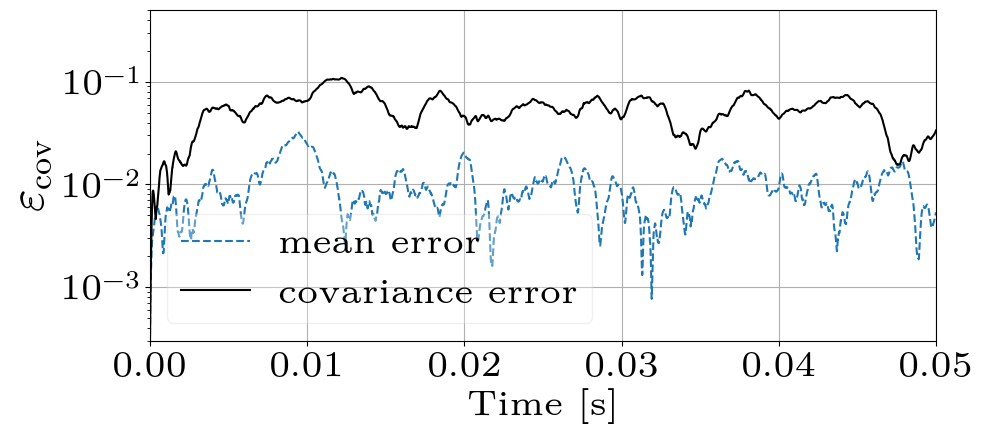

In [26]:
results = stoOpinf.analyze_rom_results(
    E_error, C_error,
    Eopinfs, Copinfs,
    Er_data, Cr_data,
    tt, N_reg, H_reg, sigma, L,
)
Eopinf_opt = results["Eopinf_opt"]
Copinf_opt = results["Copinf_opt"]
i_Emin, j_Emin = results["i_Emin"], results["j_Emin"]
i_Cmin, j_Cmin = results["i_Cmin"], results["j_Cmin"]

EROM_opt = EROM[i_Emin][j_Emin]

In [27]:
# Ahatr = ROMs_all[i_Emin][j_Emin]['Ahat']
# Nhatr = ROMs_all[i_Emin][j_Emin]['Nhat']
# Bhatr = ROMs_all[i_Emin][j_Emin]['Bhat']
# display(Math(r"\|A_r\|_F = %.2e" % la.norm(Ahatr, 'fro')))
# display(Math(r"\|B_r\|_F = %.2e" % la.norm(Bhatr, 'fro')))
# display(Math(r"\|N_r\|_F = %.2e" % la.norm(Nhatr, 'fro')))

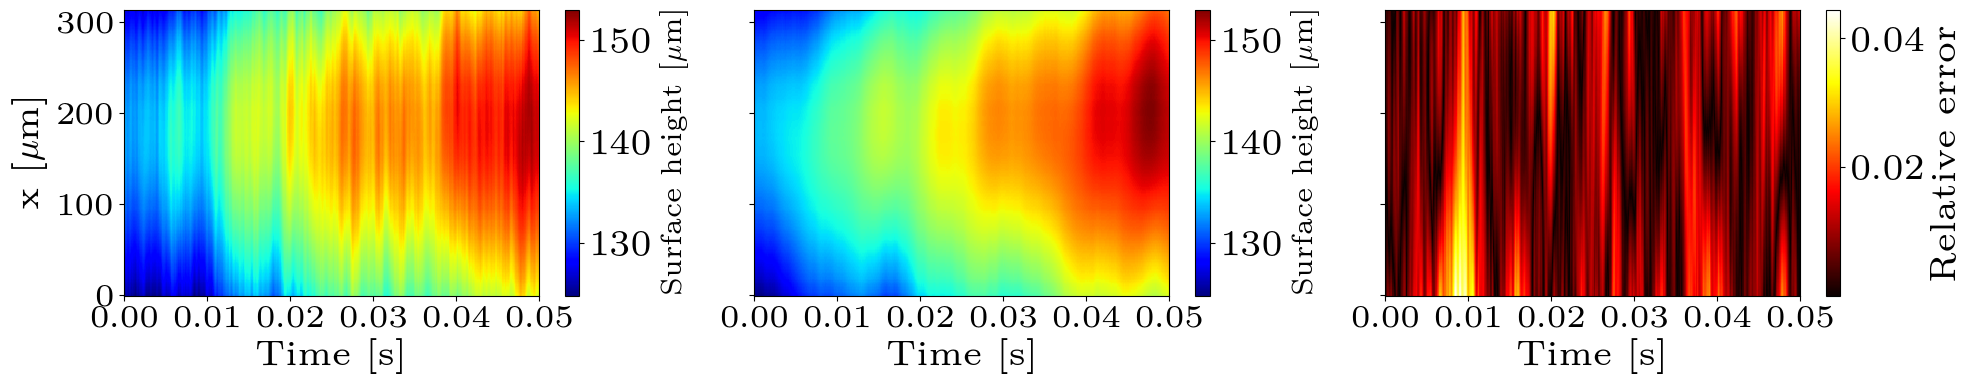

In [28]:
i_center = 100

T, X = np.meshgrid(tt, x)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 4), sharey=True)

xticks = np.arange(0, 0.06, 0.01)
vmin = min(Edata[i_center, :].min(), EROM_opt.min())
vmax = max(Edata[i_center, :].max(), EROM_opt.max())

pcm1 = ax1.pcolormesh(T, X, Edata, shading='auto', cmap='jet', vmin=vmin, vmax=vmax)
ax1.set_xlabel('Time [s]', fontsize=25)
ax1.set_ylabel('x [$\\mu$m]', fontsize=25)
ax1.set_xticks(xticks)
ax1.tick_params(axis='both', labelsize=23)
cbar1 = fig.colorbar(pcm1, ax=ax1)  
cbar1.ax.tick_params(labelsize=25)
cbar1.set_label('Surface height [$\\mu$m]', fontsize=20)

pcm2 = ax2.pcolormesh(T, X, EROM_opt, shading='auto', cmap='jet', vmin=vmin, vmax=vmax)
ax2.set_xlabel('Time [s]', fontsize=25)
ax2.set_xticks(xticks)
ax2.tick_params(axis='both', labelsize=23)
cbar2 = fig.colorbar(pcm2, ax=ax2)
cbar2.ax.tick_params(labelsize=25)
cbar2.set_label('Surface height [$\\mu$m]', fontsize=20)

pcm3 = ax3.pcolormesh(T, X, abs(Edata - EROM_opt) / abs(Edata), shading='auto', cmap='hot')
ax3.set_xlabel('Time [s]', fontsize=25)
ax3.set_xticks(xticks)
ax3.tick_params(axis='both', labelsize=23)
cbar3 = fig.colorbar(pcm3, ax=ax3)
cbar3.ax.tick_params(labelsize=25)
cbar3.set_label('Relative error', fontsize=25)

plt.tight_layout()
plt.show()

## **Testing on unseen data**

In [5]:
power = "0p04"  # Ca_ac = 0.25 x 10^-3

dataset = stoOpinf.QDataset.load(power, power_labels[power]).preprocess()
X, t, x, nx = dataset.Q, dataset.t, dataset.x, dataset.nx
X_split, Xstate_all, X_mean, tt = dataset.Q_split, dataset.Qstate_all, dataset.X_mean, dataset.tt

In [84]:
testing_set_ratio = 0.5

# data parameters
_, L_all, s = Xstate_all.shape      # L: sample size, s: # of time steps
h_test = t[1] - t[0]            # time step

np.random.seed(42)
idx = np.random.choice(L_all, int(L_all*testing_set_ratio), replace=False)
idx.sort()

mask = np.ones(L_all, dtype=bool)
mask[idx] = False

Xstate_test  = Xstate_all[:, idx,  :]   # e.g., (200, 136, 5760)
Xstate_train = Xstate_all[:, mask, :]   # e.g., (200, 136, 5760)

X_train_mean = np.mean(Xstate_train, axis=1)
X_test_mean = np.mean(Xstate_test, axis=1)

In [85]:
# Basis of training data
print("Computing POD basis...")
V, S, _ = svd(Xstate_train.reshape(nx, -1), full_matrices=False)
print("Basis computed.")

Computing POD basis...
Basis computed.


In [86]:
E_train = np.mean(Xstate_train, 1)   # mean of the training data
L_train = Xstate_train.shape[1]      # number of training samples
E_test = np.mean(Xstate_test, 1)     # mean of the testing data

tt_test = tt

# Input signal
f0 = 7
f_input = f0 * 1e6
u_amp = 1
u_train = u_amp * np.cos(2 * np.pi * f_input * tt_test)

In [87]:
# Hyperparameters
A_reg_test = 0
B_reg      = 0
N_reg      = np.logspace(8, 10, 10)
H_reg      = 5e4

sigma      = 1

isbilinear = True
isBu       = True
seed_test  = 42

ROM_form = 'A' + ('B' if isBu else '') + ('N' if isbilinear else '')

# Loop ranges
if isBu:
    B_loop = np.arange(1)
    B_reg = np.array([B_reg])
    # B_reg = B_reg_arr
else:
    B_loop = np.array([0])
    B_reg  = np.array([0.0])

# Lambda factory
def get_lambda(ii, jj):
    if isbilinear and isBu:
        return np.array([A_reg_test, B_reg[jj], N_reg[ii]])
    elif isbilinear and not isBu:
        return np.array([A_reg_test, N_reg[ii]])
    elif not isbilinear and isBu:
        return np.array([A_reg[ii], B_reg[jj], 0.0])
    else:
        return np.array([A_reg[ii]])

In [ ]:
#### r sweep ####
r_candidates = np.arange(5, 31)
r_results    = {}                    

for r in r_candidates:
    Vr_temp      = V[:, :r]
    
    # Projection of training data onto the reduced basis
    X_train_temp = Vr_temp.T @ Xstate_train.reshape(Vr_temp.shape[0], L_train * s)    
    X_train_temp = X_train_temp.reshape(r, L_train, s)

    E_train = X_train_temp.mean(axis=1)
    C_train = np.stack([np.cov(X_train_temp[:, :, k])
                        for k in range(s)], axis=2)

    ROMdata = stoOpinf.StochasticOpInfTrainingData(E_train, C_train, X_train_temp, u_train, Vr_temp, h_test)
    grid = stoOpinf.RegularizationGrid(N_reg, H_reg, B_loop, get_lambda, seed_test)
    results = stoOpinf.run_grid_search(ROMdata, grid, isbilinear, isBu, sigma)

    E_error = results['E_error']   # shape (n_outer, n_inner)
    C_error = results['C_error']
    
    best_indices       = np.nanargmin(E_error)
    best_ii, best_jj   = np.unravel_index(best_indices, E_error.shape)

    r_results[r] = {
        'E_error'  : E_error[best_ii, best_jj],
        'C_error'  : C_error[best_ii, best_jj],
        'best_ii'  : best_ii, 'best_jj'  : best_jj,
        'results'  : results,
    }
    print(f"r={r:2d} | mean error={E_error[best_ii, best_jj]:.4e}  "
            f"cov error={C_error[best_ii, best_jj]:.4e}")

r= 5 | mean error=3.4926e-02  cov error=6.7355e-01
r= 6 | mean error=2.3554e-02  cov error=1.6832e+00
r= 7 | mean error=1.3660e-02  cov error=1.4370e+00
r= 8 | mean error=2.0270e-02  cov error=1.7343e+00
r= 9 | mean error=1.9553e-02  cov error=1.2156e+00
r=10 | mean error=1.3704e-02  cov error=1.2583e+00
r=11 | mean error=1.4030e-02  cov error=1.2180e+00
r=12 | mean error=3.7853e-02  cov error=2.0117e+00
r=13 | mean error=7.5507e-03  cov error=1.0541e+00
r=14 | mean error=2.6752e-02  cov error=6.0297e-01
r=15 | mean error=2.4609e-02  cov error=1.0595e+00
r=16 | mean error=2.5928e-02  cov error=4.5207e-01
r=17 | mean error=2.3044e-02  cov error=1.0052e+00
r=18 | mean error=2.3629e-02  cov error=1.0154e+00
r=19 | mean error=2.2404e-02  cov error=9.6214e-01
r=20 | mean error=3.3502e-02  cov error=7.4436e-01
r=21 | mean error=1.8503e-02  cov error=6.1561e-01
r=22 | mean error=2.4341e-02  cov error=3.5804e-01
r=23 | mean error=2.6416e-02  cov error=1.7402e-01
r=24 | mean error=3.5903e-01  c

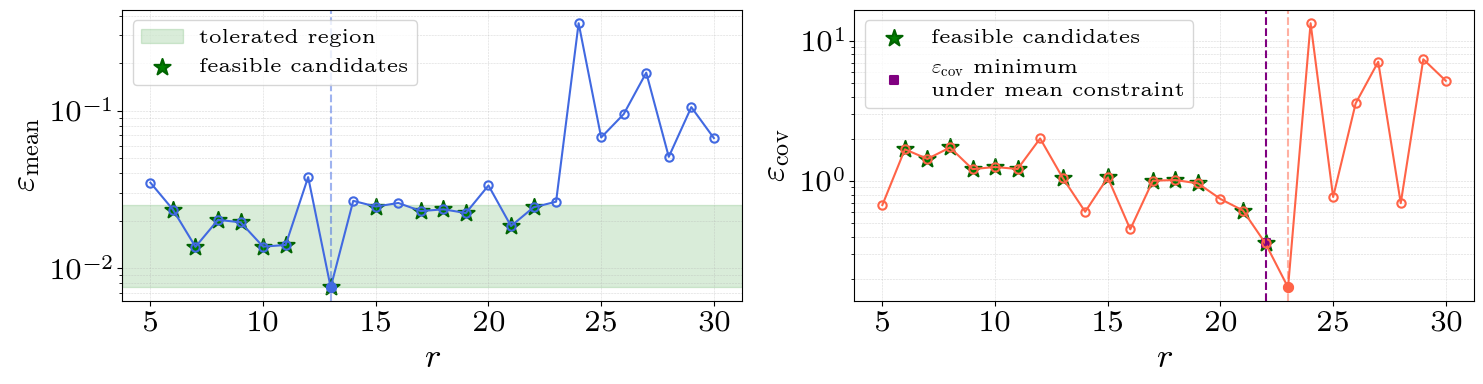

In [92]:
r_candidates = np.array(sorted(r_results.keys()))

E_errs = np.array([r_results[r]['E_error'] for r in r_candidates])
C_errs = np.array([r_results[r]['C_error'] for r in r_candidates])

E_min = np.min(E_errs)
E_max = np.max(E_errs)

tol = E_max - E_min
tol = 0.05 * tol

valid_mask = E_errs <= E_min + tol
valid_idx = np.where(valid_mask)[0]

# constrained optimum (min C in feasible region)
r_opt_C_given_E_idx = valid_idx[np.argmin(C_errs[valid_idx])]
r_opt_C_given_E = r_candidates[r_opt_C_given_E_idx]

# standard optima
r_opt_E   = r_candidates[np.argmin(E_errs)]
r_opt_C   = r_candidates[np.argmin(C_errs)]


fig, axes = plt.subplots(1, 2, figsize=(15, 4))

labels = ['mean', 'covariance']
colors = ['royalblue', 'tomato']
vals_list = [E_errs, C_errs]

for ax, vals, label, color, r_best in zip(
    axes, vals_list, labels, colors,
    [r_opt_E, r_opt_C]
):

    ax.plot(r_candidates, vals, '-o', color=color, linewidth=1.5,
            markerfacecolor='none', markeredgewidth=1.5, markersize=6)

    
    # E-feasible
    if label == 'mean':
        ax.axhspan(
            E_min, E_min + tol,
            color='green',
            alpha=0.15,
            label='tolerated region'
        )

        ax.scatter(r_candidates[valid_mask],
                E_errs[valid_mask],
                color='green',
                s=150, marker='*', edgecolors='darkgreen', linewidths=1.5,
                label='feasible candidates')

    # C plot
    if label == 'covariance':

        ax.scatter(r_candidates[valid_mask],
                C_errs[valid_mask],
                color='green',
                s=150, marker='*', edgecolors='darkgreen', linewidths=1.5,
                label='feasible candidates')

        ax.scatter(r_candidates[r_opt_C_given_E_idx],
                C_errs[r_opt_C_given_E_idx],
                color='purple',
                s=40, marker='s', edgecolors='purple', linewidths=1.5,
                #    zorder=6,
                label='$\\varepsilon_{\\text{cov}}$ minimum \nunder mean constraint')

        ax.axvline(r_candidates[r_opt_C_given_E_idx],
                color='purple', linestyle='--', linewidth=1.5)

    # standard optima
    best_idx = np.where(r_candidates == r_best)[0][0]
    ax.scatter(r_best, vals[best_idx], color=color, s=50, zorder=5)
    ax.axvline(r_best, color=color, linestyle='--', alpha=0.5)

    
    ax.set_xlabel('$r$', fontsize=25)
    ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.5)

axes[0].set_ylabel('$\\varepsilon_{\\text{mean}}$', fontsize=25)
axes[1].set_ylabel('$\\varepsilon_{\\text{cov}}$', fontsize=25)
axes[0].tick_params(axis='both', which='major', labelsize=20)
axes[1].tick_params(axis='both', which='major', labelsize=20)

axes[0].set_yscale('log')
axes[1].set_yscale('log')

axes[0].legend(fontsize=15)
axes[1].legend(fontsize=15)

plt.tight_layout()
plt.show()

In [105]:
r_opt = 23

# ROM basis and projections
Vr_train = V[:, :r_opt]                    # n x r

# Data projection onto the ROM basis
Xr_train = Vr_train.T @ Xstate_train.reshape(Vr_train.shape[0], L_train * s)  
Xr_train = Xr_train.reshape(r_opt, L_train, s)         # r x L x s

# mean and covariance 
Er_train = Xr_train.mean(axis=1)                 # r x s
Cr_train = np.stack([np.cov(Xr_train[:,:,k])     # r x r x s
                    for k in range(s)], axis=2)

In [106]:
rom = stoOpinf.StochasticOpInfROM(isbilinear=isbilinear, isBu=isBu)
stochasticROMdata = stoOpinf.StochasticOpInfTrainingData(Er_train, Cr_train, Xr_train, u_train, Vr_train, h_test)
grid = stoOpinf.RegularizationGrid(N_reg, H_reg, B_loop, get_lambda, seed_test) 

In [107]:
results = stoOpinf.run_grid_search(stochasticROMdata, grid, isbilinear, isBu, sigma)

Eopinfs, Copinfs = results['Eopinfs'], results['Copinfs']
EROM, CROM       = results['EROM'],    results['CROM']
E_error, C_error = results['E_error'], results['C_error']
ROMs_all         = results['ROMs_all']
Xr_opinfs        = results["Xr_opinfs"]

In [139]:
ROM_trained = ROMs_all[i_Emin][j_Emin]
Ahatr, Nhatr, Bhatr = ROM_trained['Ahat'], ROM_trained['Nhat'], ROM_trained['Bhat']
Mhatr, Ehatr        = ROM_trained['Mhat'], ROM_trained['Ehat']

In [140]:
# ROM step function
np.random.seed(seed_test)

# from numba import jit
# @jit(nopython=True)
def fhatr(x0, u, L_batch, k, noise_k, 
            _E=Ehatr, _A=Ahatr, _B=Bhatr, _N=Nhatr, _M=Mhatr):
    lhs   = _E - h_test*_A - h_test*_N*u
    noise = np.sqrt(h_test) * _M * sigma @ noise_k
    hBu   = (h_test * _B * u).reshape(-1, 1)
    rhs   = x0 + hBu + noise
    return np.linalg.solve(lhs, rhs)

# Project testing data onto the POD basis
L_test, s = Xstate_test.shape[1], Xstate_test.shape[2]
Xr_test = Vr_train.T @ Xstate_test.reshape(Vr_train.shape[0], L_test*s)

# Testing initial condition
xr0_test = Xr_test.reshape(r_opt, L_test, s)[:,:,0]  # r x L

# Simulate ROM
Eopinf_test, Copinf_test, Xr_opinf_test = stoOpinf.compute_model(
    fhatr, xr0_test, u_train, L_test, L_test, Mhatr.shape[1])

# Lifting back to the full space
EROM_test = Vr_train @ Eopinf_test

## **Bispectrum**

In [ ]:
import bis_bic as bisbic 
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [124]:
FB_LOW       = 150                   
FB_HIGH      = 57_000               
FS           = 115_200
SAVE_PLOTS   = False                 

PROFILE_F1_HZ = 2500  

cmap_quantity = LinearSegmentedColormap.from_list(
    'custom_thermal',
    ['#082567', '#235b9c', '#1889c7', '#62b2b6',
     '#b7d8b5', '#eed7b5', '#f4c29c'], N=256)

cmap_error = LinearSegmentedColormap.from_list(
    'custom_thermal',
    ["#FFFFFF", "#ffd0d0", "#ff8f8f", "#fc5a5a",
     "#ff3d3d", "#ff0000", "#d60000"], N=256)


In [120]:
# FOM bispectrum and bicoherence
f_wav, Bi_spec_fom, Bico_fom = bisbic.wav_bicoherence(
    E_test[100,:], tt, FS, fb_low=FB_LOW, fb_high=FB_HIGH, scales=None, Ns=2**10, wavelet='cgau1'
)
Z_bis_fom = np.log10(Bi_spec_fom)

# ROM bispectrum and bicoherence 
f_wav, Bi_spec_rom, Bico_rom = bisbic.wav_bicoherence(
    EROM_test[100,:], tt, FS, fb_low=FB_LOW, fb_high=FB_HIGH, scales=None, Ns=2**10, wavelet='cgau1'
)
Z_bis_rom = np.log10(Bi_spec_rom)

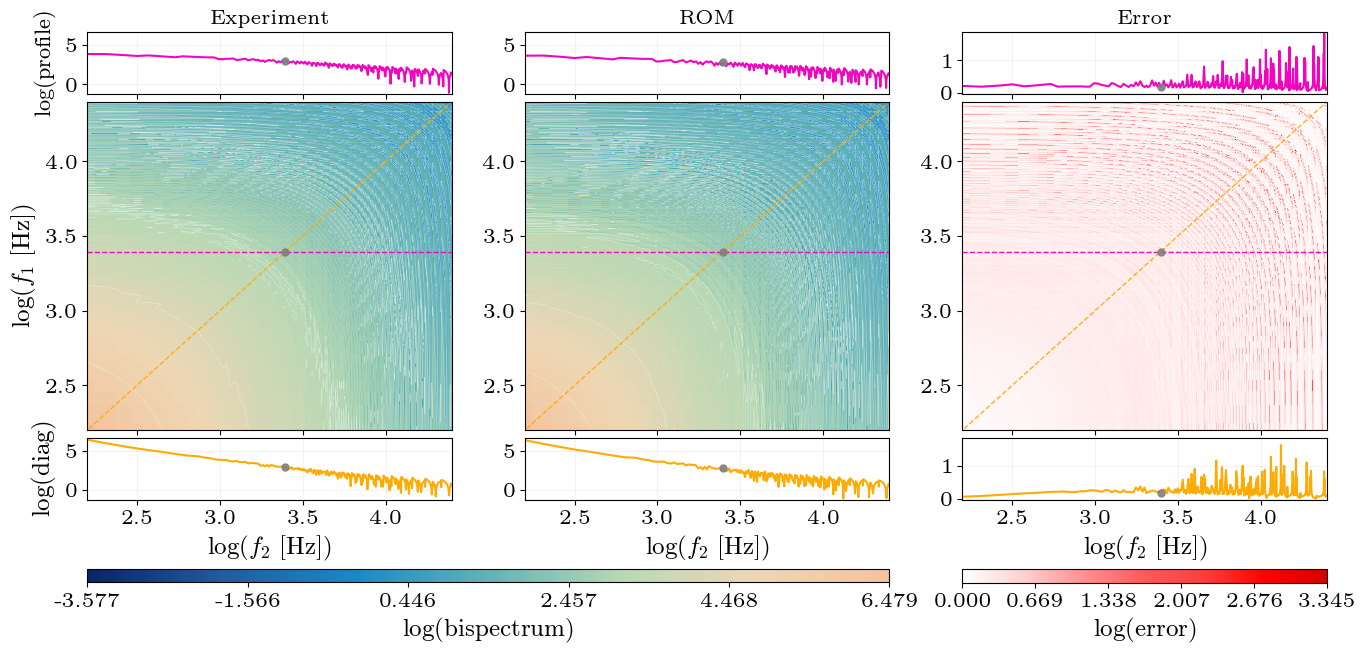

In [ ]:
# Error
Z_err = np.abs(Z_bis_fom - Z_bis_rom)

vmin_main = min(Z_bis_fom.min(), Z_bis_rom.min())
vmax_main = max(Z_bis_fom.max(), Z_bis_rom.max())

vmin_err = Z_err.min()
vmax_err = Z_err.max()

datasets = [
    ("Experiment", f_wav, Z_bis_fom, (vmin_main, vmax_main)),
    ("ROM", f_wav, Z_bis_rom, (vmin_main, vmax_main)),
    ("Error", f_wav, Z_err, (vmin_err, vmax_err)),
]

ref_top_ax = ref_bot_ax = None
err_top_ax = err_bot_ax = None

fig = plt.figure(figsize=(16, 7.5))
outer_gs = GridSpec(1, 3, figure=fig, wspace=0.2)

# Precompute
logf = np.log10(f_wav)
idx_f1 = np.argmin(np.abs(f_wav - PROFILE_F1_HZ))
logf_profile = logf[idx_f1]

pc_main = None
pc_err = None

axes_main = []
axes_err = []

for col, (title, f_wav, Z_bis, (vmin, vmax)) in enumerate(datasets):

    gs = GridSpecFromSubplotSpec(
        3, 1,
        height_ratios=[1, 5.3, 1],
        hspace=0.05,
        subplot_spec=outer_gs[col]
    )

    is_error = title == "Error"

    # Axis sharing
    bisp_top = fig.add_subplot(gs[0], sharey=None if is_error else ref_top_ax)
    bisp_mid = fig.add_subplot(gs[1], sharex=bisp_top)
    bisp_bot = fig.add_subplot(gs[2], sharex=bisp_top,
                            sharey=None if is_error else ref_bot_ax)

    if is_error:
        axes_err.extend([bisp_top, bisp_mid, bisp_bot])
        cmap = cmap_error
    else:
        axes_main.extend([bisp_top, bisp_mid, bisp_bot])
        cmap = cmap_quantity

    if not is_error:
        ref_top_ax = ref_top_ax or bisp_top
        ref_bot_ax = ref_bot_ax or bisp_bot
    else:
        err_top_ax, err_bot_ax = bisp_top, bisp_bot


    # Profile
    profile_trace = Z_bis[idx_f1, :]
    bisp_top.plot(logf, profile_trace, color="#f205bf", lw=1.5)
    bisp_top.plot(logf_profile, Z_bis[idx_f1, idx_f1],
                  'o', color='gray', ms=5, alpha=0.9)

    bisp_top.set_title(title, fontsize=14)
    bisp_top.set_ylabel(r'$\log(\mathrm{profile})$', fontsize=16)
    bisp_top.grid(True, alpha=0.25, lw=0.4)
    bisp_top.tick_params(labelbottom=False)

    # Bispectrum
    pc = bisp_mid.pcolormesh(
        logf, logf, Z_bis,
        cmap=cmap,
        shading='auto',
        vmin=vmin, vmax=vmax
    )

    # store handles
    if is_error:
        pc_err = pc
    else:
        pc_main = pc

    if not is_error:
        levels = np.linspace(vmin, vmax, 10)
        bisp_mid.contour(
            logf, logf, Z_bis,
            levels=levels,
            colors='white', linewidths=0.25, alpha=0.7
        )

    bisp_mid.set_xlim(2.2, 4.4)
    bisp_mid.set_ylim(2.2, 4.4)

    bisp_mid.plot([logf[0], logf[-1]], [logf[0], logf[-1]],
                  '--', color="#ffab03", lw=1, alpha=0.9)
    bisp_mid.axhline(logf_profile, ls='--', color="#f205bf", lw=1.0)

    bisp_mid.plot(logf_profile, logf_profile,
                  'o', ms=5, color='gray', zorder=5, alpha=0.9)

    bisp_mid.set_ylabel(r'$\log(f_1 \ [\mathrm{Hz}])$', fontsize=18)
    bisp_mid.tick_params(labelbottom=False)

    # Diagonal
    diag_trace = np.diag(Z_bis)
    bisp_bot.plot(logf, diag_trace, color="#ffab03", lw=1.5)
    bisp_bot.plot(logf_profile, Z_bis[idx_f1, idx_f1],
                  'o', color='gray', ms=5, alpha=0.9)

    bisp_bot.grid(True, alpha=0.25, lw=0.4)
    bisp_bot.set_xlabel(r'$\log(f_2 \ [\mathrm{Hz}])$', fontsize=18)
    bisp_bot.set_ylabel(r'$\log(\mathrm{diag})$', fontsize=16)
    
    # hide y-axis labels
    if col > 0:
        bisp_top.set_ylabel("")
        bisp_mid.set_ylabel("")
        bisp_bot.set_ylabel("")
        # bisp_mid.tick_params(labelleft=False)


# Y limits
def pad(arr):
    ptp = np.ptp(arr)
    if ptp == 0:
        return arr.min() - 1e-6, arr.max() + 1e-6
    return arr.min() - 0.02 * ptp, arr.max() + 0.02 * ptp

profile_vals = np.concatenate([
    Z_bis_fom[idx_f1, :],
    Z_bis_rom[idx_f1, :],
    np.diag(Z_bis_fom),
    np.diag(Z_bis_rom)
])

error_vals = np.concatenate([
    Z_err[idx_f1, :],
    np.diag(Z_err)
])

ref_top_ax.set_ylim(*pad(profile_vals))
ref_bot_ax.set_ylim(*pad(profile_vals))
err_top_ax.set_ylim(*pad(error_vals))
err_bot_ax.set_ylim(*pad(error_vals))


# Shared horizontal colorbar (Exp + ROM only)
cbar_main = fig.colorbar(
    pc_main,
    ax=axes_main,
    orientation='horizontal',
    pad=0.12,
    fraction=0.07,
    aspect=60
)

ticks_main = np.linspace(vmin_main, vmax_main, 6)
cbar_main.set_ticks(ticks_main)
cbar_main.set_ticklabels([f"{t:.3f}" for t in ticks_main])
cbar_main.set_label(r'$\log(\mathrm{bispectrum})$', fontsize=18)


# Separate horizontal colorbar (Error only)
cbar_err = fig.colorbar(
    pc_err,
    ax=axes_err,
    orientation='horizontal',
    pad=0.12,
    fraction=0.07,
    aspect=27
)

ticks_err = np.linspace(vmin_err, vmax_err, 6)
cbar_err.set_ticks(ticks_err)
cbar_err.set_ticklabels([f"{t:.3f}" for t in ticks_err])
cbar_err.set_label(r'$\log(\mathrm{error})$', fontsize=18)

plt.show()

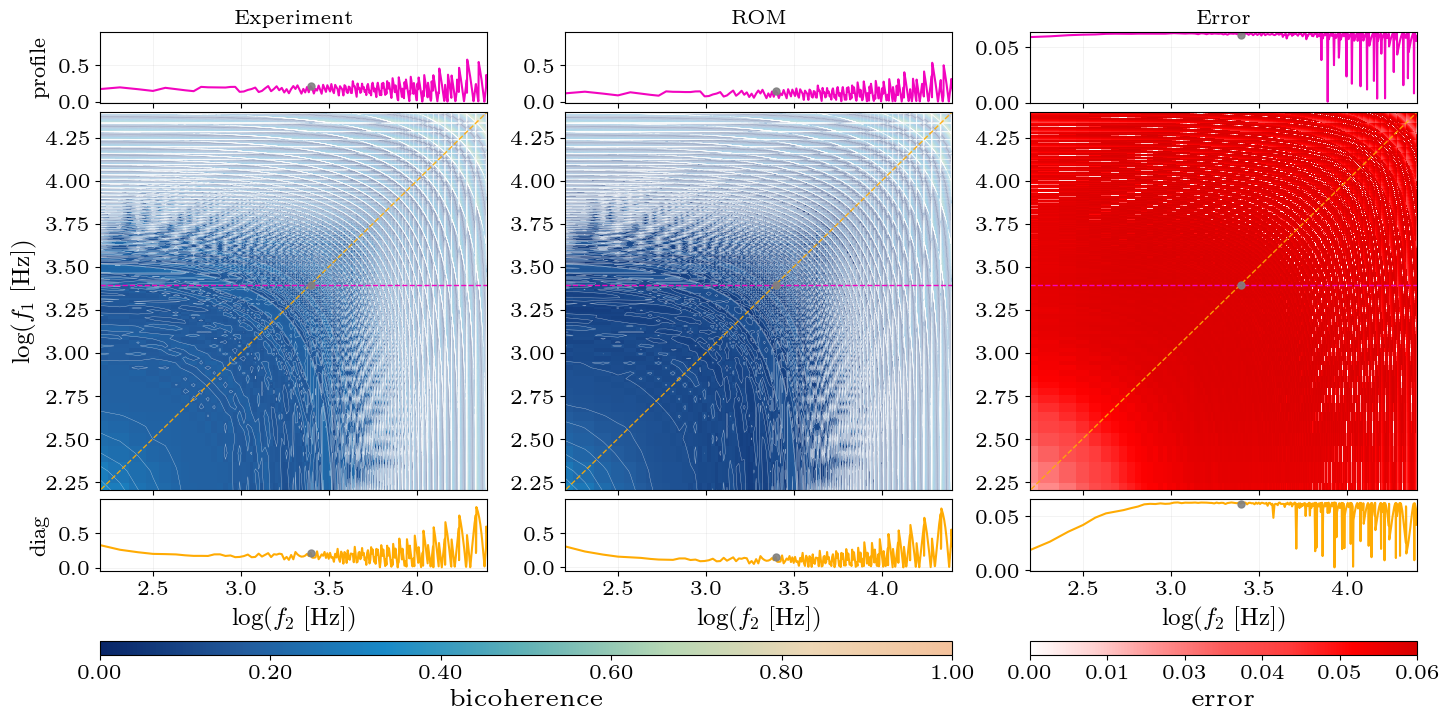

In [ ]:
# Error
Z_bic_err = np.abs(Bico_fom - Bico_rom)

vmin_global, vmax_global = 0, 1  # for FOM/ROM only

datasets = [
    ("Experiment", Bico_fom),
    ("ROM", Bico_rom),
    ("Error", Z_bic_err),
]

fig = plt.figure(figsize=(17, 7))
outer_gs = GridSpec(1, 3, figure=fig, wspace=0.2)

# Precompute
logf = np.log10(f_wav)
idx_f1 = np.argmin(np.abs(f_wav - PROFILE_F1_HZ))
logf_profile = logf[idx_f1]

# Track axes + colorbar handles
axes_main = []
axes_err = []

pc_main = None
pc_err = None

for col, (title, Z_bic) in enumerate(datasets):

    gs = GridSpecFromSubplotSpec(
        3, 1,
        height_ratios=[1, 5.3, 1],
        hspace=0.05,
        subplot_spec=outer_gs[col]
    )

    is_error = title == "Error"

    bic_top = fig.add_subplot(gs[0])
    bic_mid = fig.add_subplot(gs[1], sharex=bic_top)
    bic_bot = fig.add_subplot(gs[2], sharex=bic_top)

    # --- Track axes ---
    if is_error:
        axes_err.extend([bic_top, bic_mid, bic_bot])
    else:
        axes_main.extend([bic_top, bic_mid, bic_bot])

    # --- Profile ---
    profile_trace = Z_bic[idx_f1, :]

    bic_top.plot(logf, profile_trace, color="#f205bf", lw=1.5)
    bic_top.plot(logf_profile, Z_bic[idx_f1, idx_f1],
                 'o', color='gray', ms=5, alpha=0.9)

    bic_top.set_title(title, fontsize=14)
    bic_top.set_ylabel(r'$\mathrm{profile}$', fontsize=16)
    bic_top.grid(True, alpha=0.25, lw=0.4)
    bic_top.tick_params(labelbottom=False)

    # Color scaling
    if is_error:
        vmin, vmax = Z_bic_err.min(), Z_bic_err.max()
        cmap = cmap_error
    else:
        vmin, vmax = vmin_global, vmax_global
        cmap = cmap_quantity

    # Heatmap
    pc = bic_mid.pcolormesh(
        logf, logf, Z_bic,
        cmap=cmap,
        shading='auto',
        vmin=vmin, vmax=vmax
    )

    # store colorbar handles
    if is_error:
        pc_err = pc
    else:
        pc_main = pc

    # Contours only for FOM/ROM
    if not is_error:
        levels = np.arange(0, 1, 0.025)
        bic_mid.contour(
            logf, logf, Z_bic,
            levels=levels,
            colors='white', linewidths=0.25, alpha=0.7
        )

    bic_mid.set_xlim(2.2, 4.4)
    bic_mid.set_ylim(2.2, 4.4)

    bic_mid.plot([logf[0], logf[-1]], [logf[0], logf[-1]],
                 '--', color="#ffab03", lw=1, alpha=0.9)

    bic_mid.axhline(logf_profile, ls='--', color="#f205bf", lw=1.0)
    bic_mid.plot(logf_profile, logf_profile,
                 'o', ms=5, color='gray', zorder=5, alpha=0.9)

    bic_mid.set_ylabel(r'$\log(f_1 \ [\mathrm{Hz}])$', fontsize=18)
    bic_mid.tick_params(labelbottom=False)

    # Diagonal
    diag_trace = np.diag(Z_bic)

    bic_bot.plot(logf, diag_trace, color="#ffab03", lw=1.5)
    bic_bot.plot(logf_profile, Z_bic[idx_f1, idx_f1],
                 'o', color='gray', ms=5, alpha=0.9)

    bic_bot.grid(True, alpha=0.25, lw=0.4)
    bic_bot.set_ylabel(r'$\mathrm{diag}$', fontsize=16)
    bic_bot.set_xlabel(r'$\log(f_2 \ [\mathrm{Hz}])$', fontsize=18)

    bic_top.set_xlim(bic_mid.get_xlim())
    
    # hide y-axis labels
    if col > 0:
        bic_top.set_ylabel("")
        bic_mid.set_ylabel("")
        bic_bot.set_ylabel("")
        # bic_mid.tick_params(labelleft=False)


# Y-limits
def padded_limits(arr):
    ptp = np.ptp(arr)
    if ptp == 0:
        return arr.min() - 1e-6, arr.max() + 1e-6
    return arr.min() - 0.02 * ptp, arr.max() + 0.02 * ptp


profile_vals = np.concatenate([
    Bico_fom[idx_f1, :],
    Bico_rom[idx_f1, :],
    np.diag(Bico_fom),
    np.diag(Bico_rom)
])

error_vals = np.concatenate([
    Z_bic_err[idx_f1, :],
    np.diag(Z_bic_err)
])

# Apply limits
axes_main_top = axes_main[:3]
axes_main_bot = axes_main[-3:]

axes_err_top = axes_err[:3]
axes_err_bot = axes_err[-3:]

axes_main_top[0].set_ylim(*padded_limits(profile_vals))
axes_main_bot[0].set_ylim(*padded_limits(profile_vals))

axes_err_top[0].set_ylim(*padded_limits(error_vals))
axes_err_bot[0].set_ylim(*padded_limits(error_vals))


# Colorbar placement (perfect alignment)
def get_bbox(ax_list):
    x0 = min(ax.get_position().x0 for ax in ax_list)
    x1 = max(ax.get_position().x1 for ax in ax_list)
    y0 = min(ax.get_position().y0 for ax in ax_list)
    return x0, x1, y0


x0_main, x1_main, y0_main = get_bbox(axes_main)
x0_err, x1_err, y0_err = get_bbox(axes_err)

cbar_h = 0.02
gap = 0.12
y_cbar = min(y0_main, y0_err) - gap


# Main colorbar (Data/ROM)
cax_main = fig.add_axes([x0_main, y_cbar, x1_main - x0_main, cbar_h])
cbar_main = fig.colorbar(pc_main, cax=cax_main, orientation='horizontal')

ticks_main = np.linspace(vmin_global, vmax_global, 6)
cbar_main.set_ticks(ticks_main)
cbar_main.set_ticklabels([f"{t:.2f}" for t in ticks_main])
cbar_main.set_label('bicoherence', fontsize=18)


# Error colorbar
cax_err = fig.add_axes([x0_err, y_cbar, x1_err - x0_err, cbar_h])
cbar_err = fig.colorbar(pc_err, cax=cax_err, orientation='horizontal')

ticks_err = np.linspace(Z_bic_err.min(), Z_bic_err.max(), 6)
cbar_err.set_ticks(ticks_err)
cbar_err.set_ticklabels([f"{t:.2f}" for t in ticks_err])
cbar_err.set_label('error', fontsize=18)

plt.show()